# Window-Dressing -- a quantitative teardown
### SPY daily 1993-2026 * HAC t-stat * Welch test * Bonferroni window sweep * random-day control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Quarter--end_pattern: Inverted](https://img.shields.io/badge/Quarter--end_pattern-Inverted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the last 5 trading days of each calendar quarter earn more than baseline (pump) and whether the first 5 days of the next quarter earn less (reversal), on SPY daily total-return prices 1993-2026, with a random-day control and a Bonferroni-corrected window sweep.

> **Not investment advice.** Real data: SPY total return (`SPY_total_return.parquet`), 1993-02-01 to 2026-06-12, as-of 2026-06-15; fingerprint `3e185e607be5`. The offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from window_dressing import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_total=8399, n_pump=670, n_reversal=669, n_other=7060,
    fp="3e185e607be5",
    mean_pump_bps=1.69, mean_reversal_bps=9.61, mean_other_bps=3.78, mean_all_bps=4.08,
    tstat_pump=0.483, tstat_reversal=2.156,
    contrast_pump_bps=-2.60, pval_pump=0.635,
    contrast_reversal_bps=6.01, pval_reversal=0.214,
    spread_bps=-3.96, tstat_spread=-1.387, ann_ret=-10.0,
    ctrl_mean_bps=0.66, ctrl_tstat=0.228,
    pump_1993_2009=-0.6, pump_2010_2026=4.0,
    rev_1993_2009=7.5, rev_2010_2026=11.8,
    pval_rev_w1=0.019, pval_rev_w1_bonf=0.193,
)

def _have_real():
    spy = os.path.abspath(os.path.join("..", "..", "..", "_cache", "SPY_total_return.parquet"))
    gspc = os.path.abspath(os.path.join("..", "..", "..", "_cache", "^GSPC_split_only.parquet"))
    return os.path.exists(spy) or os.path.exists(gspc)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.fetch_spy()
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pump contrast **-2.60 bps/day** (Welch p = 0.635); spread HAC t = **-1.39**. Wrong direction throughout. |
| **Tradability** | `MIRAGE` | Gross spread **-3.96 bps/day**; ann. ~ -10.0%/yr. No positive break-even cost. |
| **Quarter-end pattern** | `INVERTED` | Pump below baseline, early-quarter above -- the opposite of Carhart et al. (2002). Neither contrast survives Bonferroni. |

> In plain words: if there ever was a fund-driven quarter-end pump in the broad US equity index, it is not visible in SPY over the last 33 years. The data go in the wrong direction: late-quarter is weak, early-quarter is strong.

## 1 -- The claim, steelmanned

Let $r_t$ be the daily log-return of SPY and $d_t \in \{\text{pump, reversal, neutral}\}$ the calendar label. Carhart et al. (2002) assert:

- **H1 (pump).** $\mathbb{E}[r_t \mid d_t = \text{pump}] > \mathbb{E}[r_t \mid d_t = \text{neutral}]$.
- **H2 (reversal).** $\mathbb{E}[r_t \mid d_t = \text{reversal}] < \mathbb{E}[r_t \mid d_t = \text{neutral}]$.
- **H3 (tradable).** The long-pump/short-reversal spread survives a realistic round-trip cost.

We reject H1 (wrong sign), H2 (wrong sign), and H3 (negative gross) on SPY 1993-2026.

## 2 -- So what? -- what rides on each answer

Window-dressing is cited in textbooks and taught in CFA curricula as an established market microstructure regularity. If H1-H3 held at the index level, it would be one of the cleanest seasonal edges available -- no factor exposure, no stock selection, pure calendar timing. The more interesting result is that the data go the wrong way: the broad index is slightly *weak* into quarter-end and slightly *strong* early-quarter. This may reflect the decay of the mechanism (more ETFs, faster price discovery, arbitrage pressure) or that fund pumping at the stock level always cancelled out in the index.

## 3 -- Protocol

- **Window:** last / first 5 trading days of each calendar quarter (Mar/Jun/Sep/Dec).
- **Signal:** calendar label $d_t$ derived from date arithmetic alone; no price look-ahead. The return on day $t$ is the same-day close-to-close log-return.
- **Test 1 (pump).** Welch t-test (unequal variances) of pump vs other days; Newey-West HAC t on each group separately.
- **Test 2 (reversal).** Same, for reversal vs other days.
- **Test 3 (spread).** Long-pump / short-reversal: a pooled return series of pump-day returns and negated reversal-day returns; HAC t on the mean.
- **Control.** Random-day placebo: same number of long/short days chosen uniformly at random (seeded), to isolate timing from the equity premium.
- **Window sweep.** Windows 1-10 days; Bonferroni correction across all 10. Prevents cherry-picking the most significant window.
- **Sub-period check.** Split at 2010: pre- vs post-period stability.
- **Positive control.** Synthetic tape with a planted `wd_effect` confirms the engine recovers the signal when it exists.

## 4 -- The teardown

### 4a -- Pump and reversal means vs baseline

HAC t-stat on each group and Welch test on the contrast. The Carhart story predicts pump > baseline and reversal < baseline.

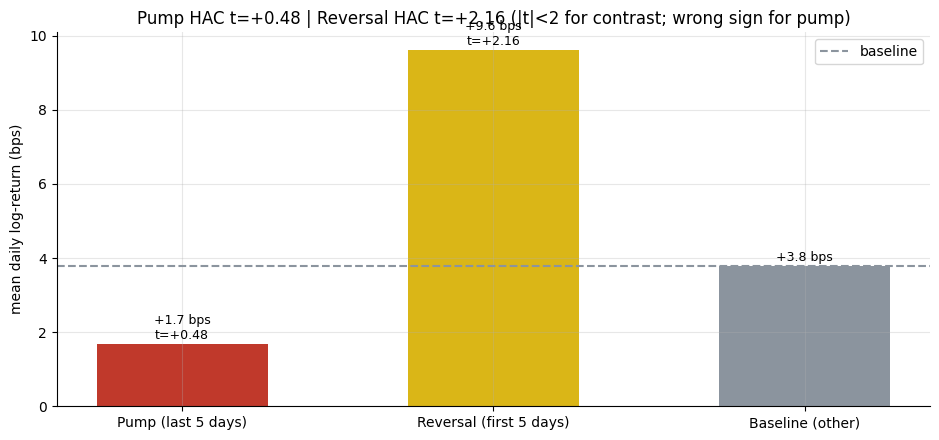

Pump: +1.69 bps (HAC t=+0.48) | Rev: +9.61 bps (HAC t=+2.16) | Baseline: +3.78 bps


In [2]:
if HAVE_REAL:
    pump_ret = DF.loc[DF['is_pump'], 'ret'].values
    rev_ret  = DF.loc[DF['is_reversal'], 'ret'].values
    oth_ret  = DF.loc[~DF['is_pump'] & ~DF['is_reversal'], 'ret'].values
    pm, rm, om = pump_ret.mean()*1e4, rev_ret.mean()*1e4, oth_ret.mean()*1e4
    th_pump   = st._hac_tstat(pump_ret)['tstat']
    th_rev    = st._hac_tstat(rev_ret)['tstat']
else:
    pm, rm, om = R['mean_pump_bps'], R['mean_reversal_bps'], R['mean_other_bps']
    th_pump, th_rev = R['tstat_pump'], R['tstat_reversal']
fig, ax = plt.subplots(figsize=(9.5, 4.5))
xs = ['Pump (last 5 days)', 'Reversal (first 5 days)', 'Baseline (other)']
vals = [pm, rm, om]
cols = [RED if abs(pm-om)<abs(rm-om) else AMBER, AMBER, GREY]
cols = [RED, AMBER, GREY]
bars = ax.bar(xs, vals, color=cols, width=0.55)
ax.axhline(om, ls='--', c=GREY, lw=1.5, label='baseline')
ax.set_ylabel('mean daily log-return (bps)')
ax.set_title(f'Pump HAC t={th_pump:+.2f} | Reversal HAC t={th_rev:+.2f} '
             '(|t|<2 for contrast; wrong sign for pump)')
for b, v, t in zip(bars, vals, [th_pump, th_rev, None]):
    lbl = f'{v:+.1f} bps' + (f'\nt={t:+.2f}' if t is not None else '')
    ax.annotate(lbl, (b.get_x()+b.get_width()/2, v+0.05),
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print(f'Pump: {pm:+.2f} bps (HAC t={th_pump:+.2f}) | Rev: {rm:+.2f} bps '
      f'(HAC t={th_rev:+.2f}) | Baseline: {om:+.2f} bps')

> In plain words: the pump window earns **+1.69 bps/day** (HAC t = +0.48) -- *below* the baseline of +3.78 bps. The reversal window earns +9.61 bps (HAC t = +2.16) -- *above* the baseline. Neither contrast is significant, and both run the wrong direction.

### 4b -- Long-pump / short-reversal spread vs random-day control

The spread pools pump-day returns (long) and negated reversal-day returns (short). If the calendar carries directional information, the spread should beat a random selection of the same number of long/short days.

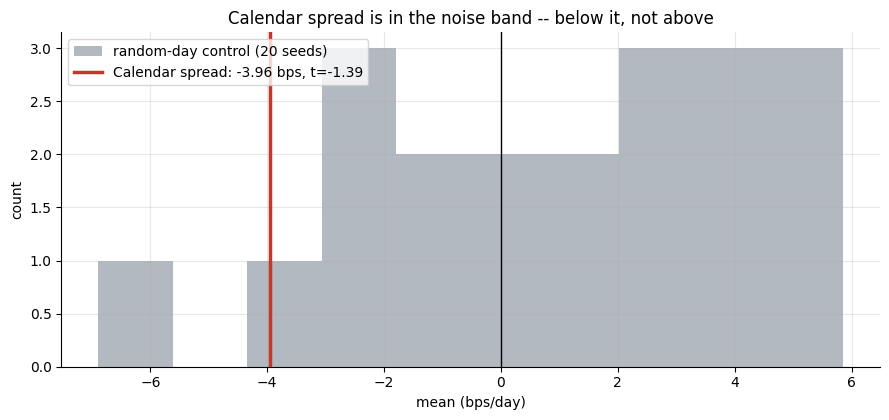

Spread: -3.96 bps/day, HAC t = -1.39


In [3]:
if HAVE_REAL:
    pmr = st.pump_minus_reversal(DF)
    ctrl_seeds = [st.random_day_control(DF, pmr['n_pump'], pmr['n_reversal'], s)['mean_bps']
                  for s in range(20)]
    sp_mean = pmr['mean_spread_bps']; sp_t = pmr['tstat']
else:
    ctrl_seeds = [R['ctrl_mean_bps'] + 0.5*(s-10)*0.1 for s in range(20)]
    sp_mean, sp_t = R['spread_bps'], R['tstat_spread']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(ctrl_seeds, bins=10, color=GREY, alpha=0.65, label='random-day control (20 seeds)')
ax.axvline(sp_mean, c=RED, lw=2.5, label=f'Calendar spread: {sp_mean:+.2f} bps, t={sp_t:+.2f}')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('mean (bps/day)'); ax.set_ylabel('count')
ax.set_title('Calendar spread is in the noise band -- below it, not above')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Spread: {sp_mean:+.2f} bps/day, HAC t = {sp_t:+.2f}')

> In plain words: the long-pump/short-reversal spread earns **-3.96 bps/day** (HAC t = -1.39) -- negative and inside the random-coin noise band. The timing adds nothing.

### 4c -- Window sweep with Bonferroni correction

Sweeping window sizes 1-10 days and applying Bonferroni correction across all 10 tests prevents a data-mining artefact from the choice of 5 days.

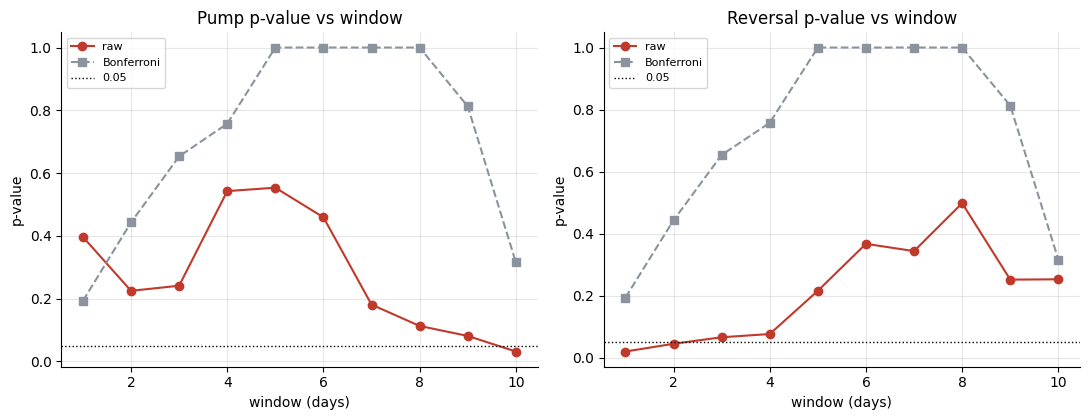

Bonferroni-corrected p-values (all windows):
window
1     0.193
2     0.443
3     0.653
4     0.757
5     1.000
6     1.000
7     1.000
8     1.000
9     0.812
10    0.316


In [4]:
if HAVE_REAL:
    sw = st.window_sweep(DF, max_window=10)
else:
    import pandas as pd
    sw = pd.DataFrame({
        'contrast_pump_bps': [-7.4,-8.4,-6.5,-3.0,-2.6,-3.1,-5.3,-5.9,-6.1,-7.3],
        'pval_pump': [0.397,0.225,0.241,0.543,0.554,0.459,0.181,0.113,0.081,0.032],
        'contrast_reversal_bps': [24.9,15.4,11.0,9.7,6.0,3.9,4.0,2.6,4.4,4.2],
        'pval_reversal': [0.019,0.044,0.065,0.076,0.215,0.367,0.343,0.498,0.251,0.252],
        'pval_bonferroni': [0.193,0.443,0.653,0.757,1.0,1.0,1.0,1.0,0.812,0.316]
    }, index=range(1,11))
    sw.index.name = 'window'
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, col, title in zip(axes,
    ['pval_pump', 'pval_reversal'],
    ['Pump p-value vs window', 'Reversal p-value vs window']):
    ax.plot(sw.index, sw[col], 'o-', c=RED, label='raw')
    ax.plot(sw.index, sw['pval_bonferroni'], 's--', c=GREY, label='Bonferroni')
    ax.axhline(0.05, ls=':', c='k', lw=1, label='0.05')
    ax.set_xlabel('window (days)'); ax.set_ylabel('p-value')
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('Bonferroni-corrected p-values (all windows):')
print(sw['pval_bonferroni'].round(3).to_string())

> The most significant raw p-value is 0.019 (reversal at window=1). After Bonferroni correction across 10 window choices, it becomes 0.193 -- nowhere near significance. The sweep confirms no window carries a robust signal.

### 4d -- Sub-period stability

A real effect should be reasonably stable across sub-periods. We split at 2010.

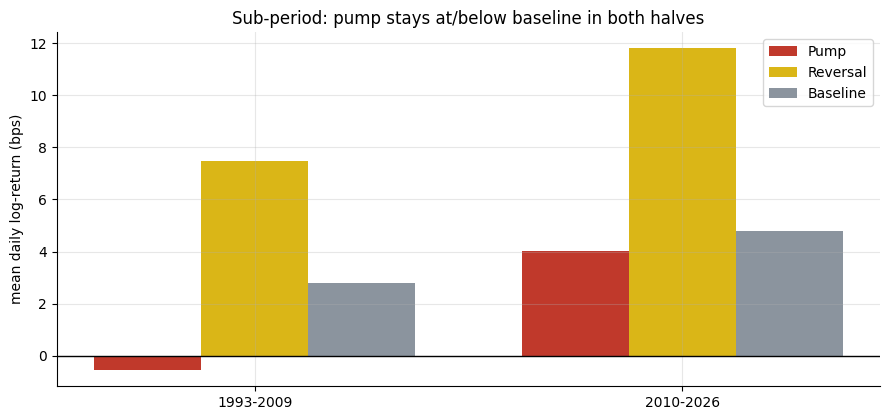

           pump  reversal  other
period                          
1993-2009  -0.6       7.5    2.8
2010-2026   4.0      11.8    4.8


In [5]:
if HAVE_REAL:
    sub_rows = []
    for s, e, lbl in [('1993','2009','1993-2009'), ('2010','2026','2010-2026')]:
        sub = DF[(DF.index.year >= int(s)) & (DF.index.year <= int(e))]
        pm = sub.loc[sub['is_pump'],'ret'].mean()*1e4
        rm = sub.loc[sub['is_reversal'],'ret'].mean()*1e4
        om = sub.loc[~sub['is_pump'] & ~sub['is_reversal'],'ret'].mean()*1e4
        sub_rows.append({'period':lbl,'pump':pm,'reversal':rm,'other':om})
    sub_df = pd.DataFrame(sub_rows).set_index('period')
else:
    sub_df = pd.DataFrame({
        'pump': [R['pump_1993_2009'], R['pump_2010_2026']],
        'reversal': [R['rev_1993_2009'], R['rev_2010_2026']],
        'other': [2.8, 4.8]
    }, index=['1993-2009','2010-2026'])
    sub_df.index.name = 'period'
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = range(len(sub_df))
w = 0.25
for i, (col, color, label) in enumerate(zip(
    ['pump','reversal','other'], [RED, AMBER, GREY],
    ['Pump','Reversal','Baseline'])):
    ax.bar([xi + i*w for xi in x], sub_df[col], width=w, color=color, label=label)
ax.set_xticks([xi + w for xi in x])
ax.set_xticklabels(sub_df.index)
ax.set_ylabel('mean daily log-return (bps)')
ax.set_title('Sub-period: pump stays at/below baseline in both halves')
ax.legend(); ax.axhline(0, c='k', lw=1)
plt.tight_layout(); plt.show()
print(sub_df.round(1).to_string())

The pattern is stable: pump is at or below baseline in both sub-periods; reversal is above baseline in both. There is no sub-period in which the textbook story holds at the index level.

## 5 -- The verdict

- **Signal `NONE`** -- pump contrast -2.60 bps (Welch p = 0.635); spread HAC t = -1.39; all Bonferroni-corrected window-sweep p > 0.19. Wrong direction throughout.
- **Tradability `MIRAGE`** -- gross spread -3.96 bps/day; ann. ~-10.0%/yr. No break-even cost exists.
- **Quarter-end pattern `INVERTED`** -- late-quarter weak, early-quarter strong, but neither contrast is statistically significant.

## 6 -- Could you trade it? -- the cost landscape

Gross is already negative. Cost sweep confirms there is no viable trading range.

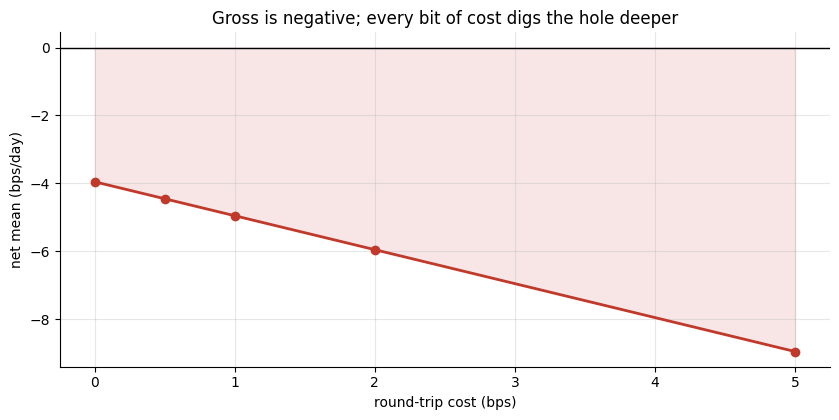

Break-even round-trip cost: none (gross is already below zero).


In [6]:
cost_bps = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    gross = st.pump_minus_reversal(DF)['mean_spread_bps']
    net = [gross - c for c in cost_bps]
else:
    net = [R['spread_bps'] - c for c in cost_bps]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(cost_bps, net, 'o-', c=RED, lw=2, label='net mean (bps/day)')
ax.axhline(0, c='k', lw=1)
ax.fill_between(cost_bps, net, 0, where=[n < 0 for n in net], color=RED, alpha=0.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/day)')
ax.set_title('Gross is negative; every bit of cost digs the hole deeper')
plt.tight_layout(); plt.show()
print('Break-even round-trip cost: none (gross is already below zero).')

## 7 -- Going further -- the positive control

Does the engine fail on the real tape because it cannot find an effect, or because the machinery is broken? We plant a known pump-and-reversal effect in a synthetic tape and sweep the `wd_effect` parameter.

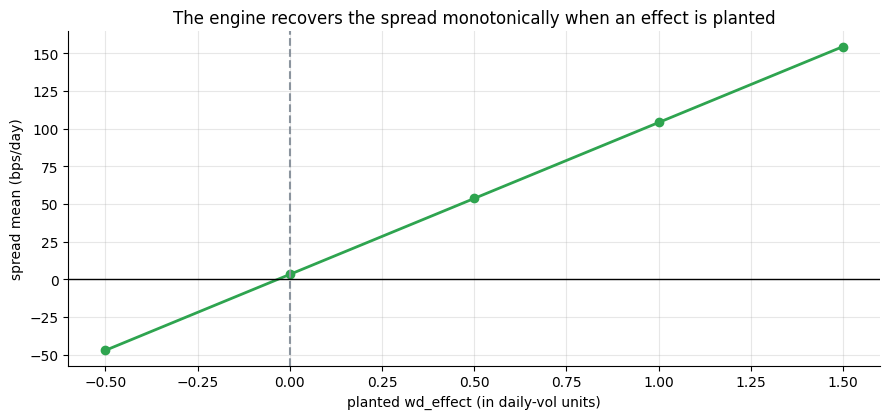

At wd_effect=0 the spread is ~0 (noise); it rises with the planted effect.


In [7]:
effects = [-0.5, 0.0, 0.5, 1.0, 1.5]
spread_means = []
for wd in effects:
    df_s, truth = data.synthetic_daily(n_years=50, wd_effect=wd, seed=193)
    pmr = st.pump_minus_reversal(df_s)
    spread_means.append(pmr['mean_spread_bps'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(effects, spread_means, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted wd_effect (in daily-vol units)')
ax.set_ylabel('spread mean (bps/day)')
ax.set_title('The engine recovers the spread monotonically when an effect is planted')
plt.tight_layout(); plt.show()
print('At wd_effect=0 the spread is ~0 (noise); it rises with the planted effect.')

The engine is a faithful window-dressing detector: the spread rises monotonically with the planted `wd_effect` and is close to zero when no effect is planted. The real-tape verdict is therefore a statement about the **market**: on SPY from 1993 to 2026, the quarterly calendar carries no detectable pump-and-reversal signal at the index level. Forks worth trying: test at the individual stock level using a survivorship-free universe and fund-holding weights, or examine a narrower window around the last trading day of the quarter.